In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score)

## Loading and viewing data

In [57]:
import pandas as pd

df = pd.read_csv("test-dataset.xlsx - test data.csv")

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  29999 non-null  int64  
 1   household_id                29999 non-null  int64  
 2   total_income                29999 non-null  str    
 3   union_name                  29999 non-null  str    
 4   user_id                     29999 non-null  int64  
 5   profile_name                29999 non-null  str    
 6   father_name                 25561 non-null  str    
 7   mother_name                 25547 non-null  str    
 8   birthday                    29999 non-null  str    
 9   age                         29999 non-null  int64  
 10  gender                      29999 non-null  str    
 11  is_poor                     29999 non-null  int64  
 12  is_freedom_fighter          29999 non-null  int64  
 13  had_stroke                  29999 non-null

In [59]:
df.head()

,Unnamed: 0,household_id,total_income,union_name,user_id,profile_name,father_name,mother_name,birthday,age,...,RESULT_STAT_BMI,SUGAR,TAG_NAME,RESULT_STAT_SUGAR,PULSE_RATE,RESULT_STAT_PR,SPO2,RESULT_STAT_SPO2,MUAC,RESULT_STAT_MUAC
0,1,241175,Lower class,KOLA,988794,মো: সাগরহোসেন,0.0,0.0,2001-11-05 18:00:00,19,...,NaN,NaN,NaN,NaN,96.0,Normal,97.0,Normal,NaN,NaN
1,2,241176,Lower class,KOLA,988796,মোছা:তামান্না,0.0,0.0,2000-06-18 18:00:00,20,...,NaN,NaN,NaN,NaN,89.0,Normal,NaN,NaN,NaN,NaN
2,3,241179,Lower class,KOLA,988802,শুকুরুচন্দ্র,0.0,0.0,1978-06-04 18:00:00,42,...,NaN,NaN,NaN,NaN,69.0,Normal,NaN,NaN,NaN,NaN
3,4,241180,Lower class,KOLA,988807,দিপালীরাণী,0.0,0.0,1956-02-02 18:00:00,64,...,NaN,8.72,Random,Normal,85.0,Normal,NaN,NaN,NaN,NaN
4,5,241181,Lower class,KOLA,988809,বুলবুলি,0.0,0.0,1996-12-25 18:00:00,23,...,NaN,NaN,NaN,NaN,101.0,High,NaN,NaN,NaN,NaN


In [60]:
df.describe()

,Unnamed: 0,household_id,user_id,age,is_poor,is_freedom_fighter,had_stroke,has_cardiovascular_disease,SYSTOLIC,DIASTOLIC,HEIGHT,WEIGHT,BMI,SUGAR,PULSE_RATE,SPO2,MUAC
count,29999.000000,29999.000000,2.999900e+04,29999.000000,29999.0,29999.000000,29999.000000,29999.000000,27600.000000,27600.000000,1128.000000,1128.000000,1128.000000,1583.000000,27455.000000,4345.000000,74.000000
mean,15000.000000,220657.302510,9.784833e+05,38.637621,0.0,0.000200,0.000767,0.001133,122.163623,76.133949,147.798502,50.027589,22.736490,9.990543,83.635913,97.627657,13.585946
std,8660.109699,158927.210137,8.081330e+05,17.494271,0.0,0.014141,0.027679,0.033647,20.863131,12.277434,22.769384,15.096071,6.036540,5.242119,12.678662,4.026527,1.266408
min,1.000000,12300.000000,9.680400e+04,0.000000,0.0,0.000000,0.000000,0.000000,52.000000,30.000000,35.560000,5.000000,1.581636,0.110000,1.000000,5.000000,11.000000
25%,7500.500000,81244.500000,3.516110e+05,26.000000,0.0,0.000000,0.000000,0.000000,107.000000,68.000000,137.160000,44.000000,18.920936,6.410000,75.000000,98.000000,13.000000
50%,15000.000000,219654.000000,9.050990e+05,37.000000,0.0,0.000000,0.000000,0.000000,120.000000,75.000000,152.400000,50.000000,21.958377,8.120000,83.000000,99.000000,13.500000
75%,22499.500000,279809.500000,1.122635e+06,50.000000,0.0,0.000000,0.000000,0.000000,132.000000,83.000000,162.560000,59.000000,25.795170,11.960000,92.000000,99.000000,14.500000
max,29999.000000,786118.000000,4.040559e+06,120.000000,0.0,1.000000,1.000000,1.000000,227.000000,144.000000,243.840000,97.000000,67.932934,35.000000,206.000000,100.000000,17.600000


In [61]:
#dropping non informative columns or columns with private information
drop_cols = ["Unnamed: 0", "profile_name", "father_name", "mother_name", "birthday", "household_id", "user_id", "union_name"]

df = df.drop(columns=drop_cols)

## Creating Health Risk Label

In [62]:
#Finding unique values in result stat columns
uniq_bp = df["RESULT_STAT_BP"].unique()
print(f"Unique values of result_stat_bp: {uniq_bp}\n")

uniq_bmi = df["RESULT_STAT_BMI"].unique()
print(f"Unique values of result_stat_bmi: {uniq_bmi}\n")

uniq_sugar = df["RESULT_STAT_SUGAR"].unique()
print(f"Unique values of result_statsugar: {uniq_sugar}\n")

uniq_pr = df["RESULT_STAT_PR"].unique()
print(f"Unique values of result_stat_pr: {uniq_pr}\n")

uniq_spo2 = df["RESULT_STAT_SPO2"].unique()
print(f"Unique values of result_stat_spo2: {uniq_spo2}\n")

uniq_muac = df["RESULT_STAT_MUAC"].unique()
print(f"Unique values of result_stat_muac: {uniq_muac}\n")

Unique values of result_stat_bp: <StringArray>
['Prehypertension',       'Mild High',          'Normal',   'Moderate High',
            'High',     'Severe High',             'Low',               nan]
Length: 8, dtype: str

Unique values of result_stat_bmi: <StringArray>
[             nan,    'Underweight',         'Normal',     'Overweight',
        'Obesity', 'Highly Obesity', 'Morbid Obesity']
Length: 7, dtype: str

Unique values of result_statsugar: <StringArray>
[                           nan,                       'Normal',
 'DIABETIC (need confirmation)',                'PRE- DIABETIC',
                         'High',            'HIGH (Borderline)',
           'LOW (Hypoglycemia)',                          'Low']
Length: 8, dtype: str

Unique values of result_stat_pr: <StringArray>
['Normal', 'High', 'Low', nan]
Length: 4, dtype: str

Unique values of result_stat_spo2: <StringArray>
['Normal', nan, 'Very low', 'Low']
Length: 4, dtype: str

Unique values of result_stat_muac: <S

In [63]:
#Checking if is_poor and is_freedom_fighter contain unique values

uniq_poor = df["is_poor"].unique()
print(f"Unique values of is_poor: {uniq_poor}\n")
#so we can drop is_poor as it only contains 0
df = df.drop(columns="is_poor")

uniq_is_ff = df["is_freedom_fighter"].unique()
print(f"Unique values of is_ff {uniq_is_ff}\n")

Unique values of is_poor: [0]

Unique values of is_ff [0 1]



In [64]:
#Normalizing the result stat
# BP
bp_high_levels = {"High","Severe High"}
bp_moderate_levels = {"Mild High", "Moderate High"}
bp_low_levels = {"Low"}

# BMI
bmi_high_levels = {"Obesity","Highly Obesity","Morbid Obesity"}
bmi_moderate_levels = {"Overweight", "Underweight"} 

# SUGAR
sugar_high_levels = {"High","HIGH (Borderline)","DIABETIC (need confirmation)"}
sugar_pre_levels = {"PRE- DIABETIC"}
sugar_low_levels = {"Low","LOW (Hypoglycemia)"}

# Pulse
pulse_abnormal_levels = {"High", "Low"}

# SPO2
spo2_low_levels = {"Low", "Very low"}

# MUAC
muac_malnutrition_levels = {"Malnutrition","Severe Malnutrition"}

In [65]:
#Adding new columns for high/low indicators
df["bp_high_flag"] = df["RESULT_STAT_BP"].isin(bp_high_levels).astype(int)
df["bp_moderate_flag"] = df["RESULT_STAT_BP"].isin(bp_moderate_levels).astype(int)
df["bp_low_flag"] = df["RESULT_STAT_BP"].isin(bp_low_levels).astype(int)

df["bmi_high_flag"] = df["RESULT_STAT_BMI"].isin(bmi_high_levels).astype(int)
df["bmi_moderate_flag"] = df["RESULT_STAT_BMI"].isin(bmi_moderate_levels).astype(int)

df["sugar_high_flag"] = df["RESULT_STAT_SUGAR"].isin(sugar_high_levels).astype(int)
df["sugar_pre_flag"] = df["RESULT_STAT_SUGAR"].isin(sugar_pre_levels).astype(int)
df["sugar_low_flag"] = df["RESULT_STAT_SUGAR"].isin(sugar_low_levels).astype(int)

df["pulse_abnormal_flag"] = df["RESULT_STAT_PR"].isin(pulse_abnormal_levels).astype(int)

df["spo2_low_flag"] = df["RESULT_STAT_SPO2"].isin(spo2_low_levels).astype(int)

df["muac_malnutrition_flag"] = df["RESULT_STAT_MUAC"].isin(muac_malnutrition_levels).astype(int)

In [66]:
#Adding a binary missing check for sparse data
for col in ["BMI", "SUGAR", "SPO2", "MUAC"]:
    df[f"{col}_missing"] = df[col].isna().astype(int)

In [67]:
#Health risk label creation
df["health_risk"] = (
    # Chronic disease risk
    (df["bp_high_flag"] == 1) |
    (df["bmi_high_flag"] == 1) |
    (df["sugar_high_flag"] == 1) |
    (df["diabetic"] == True) |
    (df["profile_hypertensive"] == True) |
    (df["had_stroke"] == 1) |
    (df["has_cardiovascular_disease"] == 1) |

    # Severe acute/nutritional risk
    (df["spo2_low_flag"] == 1) |
    (df["muac_malnutrition_flag"] == 1) |
    (df["bp_low_flag"] == 1) |
    (df["sugar_low_flag"] == 1) |
    (df["pulse_abnormal_flag"] == 1)
).astype(int)

## Saving the post processed dataset

In [68]:
#Removing columns that were used to create health risk labels
leakage_cols = [
    "diabetic", "profile_hypertensive",
    "had_stroke", "has_cardiovascular_disease",
    "bp_high_flag", "bp_low_flag", "bp_moderate_flag",
    "bmi_high_flag", "bmi_moderate_flag",
    "sugar_high_flag", "sugar_pre_flag", "sugar_low_flag",
    "spo2_low_flag", "muac_malnutrition_flag", "pulse_abnormal_flag",
    "RESULT_STAT_BP", "RESULT_STAT_BMI", "RESULT_STAT_SUGAR", "RESULT_STAT_PR", "RESULT_STAT_SPO2", "RESULT_STAT_MUAC"]

df_post = df.drop(columns=leakage_cols)

df_post.to_csv("post_processed_health_risk_dataset.csv", index=False)

print("Post-processed dataset saved successfully.")

Post-processed dataset saved successfully.


In [69]:
X = df_post.drop(columns="health_risk")
y = df_post["health_risk"]

## Pre-processing pipelines

In [70]:
numeric_features = ["age", "SYSTOLIC", "DIASTOLIC", "HEIGHT", "WEIGHT", "BMI", "SUGAR","PULSE_RATE", "SPO2", "MUAC"]

categorical_features = ["gender", "total_income", "disabilities_name", "TAG_NAME"]

binary_features = ["is_freedom_fighter","BMI_missing", "SUGAR_missing", "SPO2_missing", "MUAC_missing"]

In [71]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
    ("bin", "passthrough", binary_features)
])

## Train-Test Split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Models and Evaluation

In [73]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.75      0.98      0.85      4277
           1       0.80      0.20      0.32      1723

    accuracy                           0.76      6000
   macro avg       0.78      0.59      0.58      6000
weighted avg       0.77      0.76      0.70      6000

ROC-AUC: 0.685517468417161


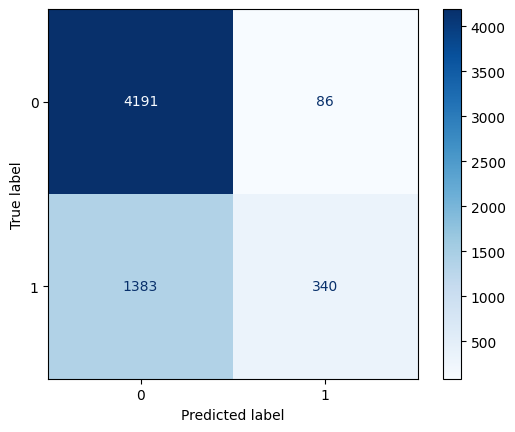

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Using the predictions from the Regression model
y_true = y_test
y_pred = y_pred

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.show()


In [75]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


              precision    recall  f1-score   support

           0       0.94      0.99      0.97      4277
           1       0.98      0.85      0.91      1723

    accuracy                           0.95      6000
   macro avg       0.96      0.92      0.94      6000
weighted avg       0.95      0.95      0.95      6000

ROC-AUC: 0.9641666048107064


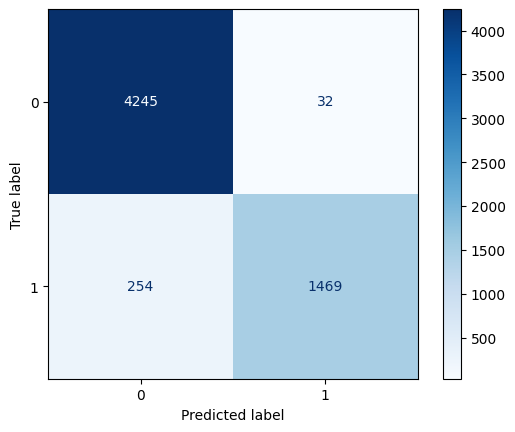

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Using the predictions from the Random Forest model
y_true = y_test
y_pred = y_pred_rf

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.show()


In [77]:
validation_cases = df.loc[X_test.index][y_test == 1].head(5)

validation_cases[[
    "diabetic", "profile_hypertensive",
    "had_stroke", "has_cardiovascular_disease",
    "bp_high_flag", "bp_low_flag", "bp_moderate_flag",
    "bmi_high_flag", "bmi_moderate_flag",
    "sugar_high_flag", "sugar_pre_flag", "sugar_low_flag",
    "spo2_low_flag", "muac_malnutrition_flag", "pulse_abnormal_flag",
    "health_risk",
]]


,diabetic,profile_hypertensive,had_stroke,has_cardiovascular_disease,bp_high_flag,bp_low_flag,bp_moderate_flag,bmi_high_flag,bmi_moderate_flag,sugar_high_flag,sugar_pre_flag,sugar_low_flag,spo2_low_flag,muac_malnutrition_flag,pulse_abnormal_flag,health_risk
16676,False,False,0,0,0,0,0,0,0,0,0,0,0,0,1,1
29715,False,False,0,0,0,1,0,0,0,0,0,0,0,0,0,1
2442,False,False,0,0,0,0,0,0,1,0,0,0,0,0,1,1
8031,False,True,0,0,0,0,1,0,0,0,0,0,0,0,0,1
7679,False,False,0,0,0,0,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14742,False,False,0,0,0,1,0,0,0,0,0,0,0,0,0,1
26630,False,False,0,0,0,1,0,0,0,0,0,0,0,0,1,1
19220,False,False,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4674,False,False,0,0,0,1,0,0,0,0,0,0,0,0,1,1
